### Exploratory Data Analysis

### Missingness Analysis

Comprehensive missingness profiling at variable, patient, and patient-variable level.  
Streak analysis distinguishes **occasional gaps**, **prolonged gaps**, and **structurally sparse variables**,  
directly supporting the imputation method choice required in the imputation step.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────
DATA_PATH        = "../data/raw/dataset_mood_smartphone.csv"
DAILY_PATH       = "../outputs/daily_aggregated.csv"   # from eda_daily_aggregation.ipynb
ID_COL           = "id"
TIME_COL         = "time"
VAR_COL          = "variable"
VAL_COL          = "value"

# Thresholds for missingness classification
OCCASIONAL_MAX   = 3    # streaks <= this many days → occasional
PROLONGED_MIN    = 7    # streaks >= this many days → prolonged
STRUCTURAL_PCT   = 70   # variable missing > this % of days → structurally sparse

MAJOR_PREDICTORS = ["mood_mean", "activity_mean", "screen_sum",
                    "circumplex.arousal_mean", "circumplex.valence_mean"]

In [7]:
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df["date"] = df[TIME_COL].dt.normalize()
df[VAL_COL] = pd.to_numeric(df[VAL_COL], errors="coerce")

day_df = pd.read_csv(DAILY_PATH, parse_dates=["date"])

ALL_VARS     = sorted(df[VAR_COL].unique())
ALL_PATIENTS = sorted(df[ID_COL].unique())
print(f"Variables: {len(ALL_VARS)}  |  Patients: {len(ALL_PATIENTS)}  |  Patient-days: {len(day_df):,}")

Variables: 19  |  Patients: 27  |  Patient-days: 1,973


#### **1. Missing % per variable**

Denominator: total possible patient-days (full calendar range × all patients).

In [8]:
# Build a full patient × date grid, then check which variable-days are present
date_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
full_index = pd.MultiIndex.from_product([ALL_PATIENTS, date_range],
                                         names=[ID_COL, "date"])
n_possible = len(full_index)   # total patient-days across all patients

# Observed patient-days per variable
obs_per_var = (
    df.groupby([VAR_COL, ID_COL, "date"])[VAL_COL]
    .count()                          # 0 if all NaN, >0 if any value
    .gt(0)
    .groupby(level=VAR_COL)
    .sum()
    .rename("n_observed_days")
)

var_miss = obs_per_var.to_frame()
var_miss["missing_%"] = (1 - var_miss["n_observed_days"] / n_possible) * 100
var_miss = var_miss.sort_values("missing_%", ascending=False).round(2)

print("Missing % per variable (sorted):")
var_miss

Missing % per variable (sorted):


,n_observed_days,missing_%
variable,,
appCat.weather,113,96.30
appCat.game,193,93.67
appCat.finance,207,93.22
appCat.unknown,264,91.35
appCat.office,276,90.95
appCat.travel,429,85.94
appCat.utilities,433,85.81
sms,734,75.94
appCat.entertainment,850,72.14


#### **2. Missing % per patient**

Denominator: that patient's own calendar range.

In [9]:
patient_rows = []

for patient, grp in df.groupby(ID_COL):
    start   = grp["date"].min()
    end     = grp["date"].max()
    n_range = (end - start).days + 1
    n_obs   = grp["date"].nunique()
    patient_rows.append({
        "patient":    patient,
        "days_range": n_range,
        "days_obs":   n_obs,
        "missing_%":  round((n_range - n_obs) / n_range * 100, 2),
    })

patient_miss = pd.DataFrame(patient_rows).set_index("patient").sort_values("missing_%", ascending=False)
print("Missing % per patient:")
patient_miss

Missing % per patient:


,days_range,days_obs,missing_%
patient,,,
AS14.28,81,58,28.40
AS14.23,77,63,18.18
AS14.29,88,73,17.05
AS14.20,78,66,15.38
AS14.08,78,67,14.10
AS14.31,90,78,13.33
AS14.12,76,67,11.84
AS14.30,78,70,10.26
AS14.27,88,80,9.09


#### **3. Missing % per patient-variable pair**

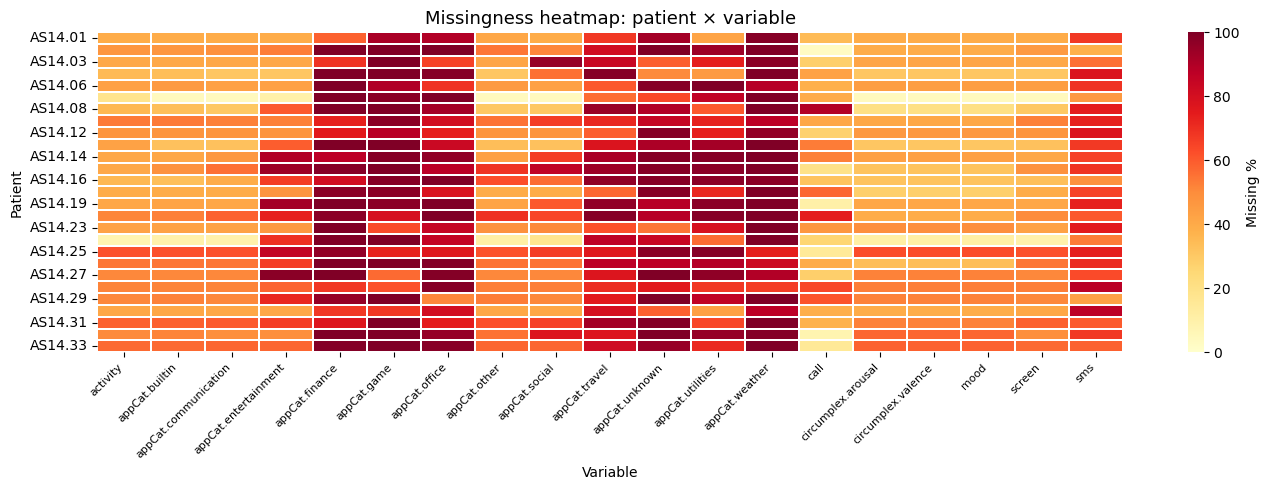

In [10]:
pv_rows = []

for patient, p_grp in df.groupby(ID_COL):
    start   = p_grp["date"].min()
    end     = p_grp["date"].max()
    n_range = (end - start).days + 1

    for var in ALL_VARS:
        n_obs = p_grp[p_grp[VAR_COL] == var]["date"].nunique()
        pv_rows.append({
            "patient":   patient,
            "variable":  var,
            "days_obs":  n_obs,
            "missing_%": round((n_range - n_obs) / n_range * 100, 2),
        })

pv_miss = pd.DataFrame(pv_rows)

# Pivot for heatmap: patients × variables
pv_pivot = pv_miss.pivot(index="patient", columns="variable", values="missing_%")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pv_pivot, ax=ax, cmap="YlOrRd", vmin=0, vmax=100,
            linewidths=0.3, cbar_kws={"label": "Missing %"})
ax.set_title("Missingness heatmap: patient × variable", fontsize=13)
ax.set_xlabel("Variable")
ax.set_ylabel("Patient")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/missingness_heatmap.png", dpi=150)
plt.show()

#### **4. Missing streak analysis per patient-variable**

For each (patient, variable) pair: number of missing streaks, average length, max length.

In [11]:
def streak_stats(observed_days: set, full_range: pd.DatetimeIndex) -> dict:
    """
    Given a set of observed dates and the full calendar range,
    return streak count, mean length, and max length of missing runs.
    """
    streaks = []
    current = 0
    for day in full_range:
        if day not in observed_days:
            current += 1
        else:
            if current > 0:
                streaks.append(current)
            current = 0
    if current > 0:
        streaks.append(current)   # trailing streak

    if not streaks:
        return {"n_streaks": 0, "mean_streak": 0.0, "max_streak": 0}
    return {
        "n_streaks":   len(streaks),
        "mean_streak": round(np.mean(streaks), 2),
        "max_streak":  int(np.max(streaks)),
    }


streak_rows = []

for patient, p_grp in df.groupby(ID_COL):
    full_range = pd.date_range(p_grp["date"].min(), p_grp["date"].max(), freq="D")

    for var in ALL_VARS:
        obs_days = set(p_grp[p_grp[VAR_COL] == var]["date"])
        s = streak_stats(obs_days, full_range)
        streak_rows.append({"patient": patient, "variable": var, **s})

streak_df = pd.DataFrame(streak_rows)

# Summary per variable across all patients
streak_summary = (
    streak_df
    .groupby("variable")
    .agg(
        mean_n_streaks   = ("n_streaks",   "mean"),
        mean_avg_streak  = ("mean_streak", "mean"),
        mean_max_streak  = ("max_streak",  "mean"),
        global_max_streak= ("max_streak",  "max"),
    )
    .round(2)
    .sort_values("global_max_streak", ascending=False)
)

print("Streak summary per variable:")
streak_summary

Streak summary per variable:


,mean_n_streaks,mean_avg_streak,mean_max_streak,global_max_streak
variable,,,,
appCat.game,3.26,46.90,62.41,104
appCat.weather,2.96,51.82,63.44,104
appCat.finance,4.56,43.29,58.89,103
appCat.office,5.74,27.02,48.26,98
appCat.unknown,5.33,28.09,48.15,88
appCat.utilities,6.96,16.46,39.41,81
appCat.entertainment,5.07,16.43,34.70,72
appCat.travel,7.81,11.28,38.00,63
appCat.communication,2.78,21.88,32.85,58


#### **5. Mood-specific day-level metrics**

In [12]:
n_total_days     = len(day_df)
n_no_mood        = (day_df["mood_available"] == 0).sum()
pct_no_mood      = n_no_mood / n_total_days * 100

# Partial availability: mood exists but at least one major predictor is missing
major_cols = [c for c in MAJOR_PREDICTORS if c in day_df.columns]
has_mood          = day_df["mood_available"] == 1
partial_mask      = has_mood & day_df[major_cols].isna().any(axis=1)
n_partial         = partial_mask.sum()
pct_partial       = n_partial / n_total_days * 100

print("=" * 52)
print("MOOD & FEATURE AVAILABILITY AT DAY LEVEL")
print("=" * 52)
print(f"  Total patient-days                    : {n_total_days:,}")
print(f"  Days with NO mood measurement         : {n_no_mood:,}  ({pct_no_mood:.1f}%)")
print(f"  Days with mood but partial features   : {n_partial:,}  ({pct_partial:.1f}%)")
print("=" * 52)

MOOD & FEATURE AVAILABILITY AT DAY LEVEL
  Total patient-days                    : 1,973
  Days with NO mood measurement         : 705  (35.7%)
  Days with mood but partial features   : 135  (6.8%)


#### **6. Missingness classification**

Each variable is assigned one label based on its missingness profile:
- **Structurally sparse** — missing > `STRUCTURAL_PCT`% of days globally
- **Prolonged gaps** — at least one patient has a max missing streak ≥ `PROLONGED_MIN` days
- **Occasional gaps** — all streaks are short (≤ `OCCASIONAL_MAX` days)

In [13]:
def classify_missingness(var: str) -> str:
    miss_pct     = var_miss.loc[var, "missing_%"] if var in var_miss.index else 0
    max_streak   = streak_summary.loc[var, "global_max_streak"] if var in streak_summary.index else 0

    if miss_pct >= STRUCTURAL_PCT:
        return "structurally_sparse"
    if max_streak >= PROLONGED_MIN:
        return "prolonged_gaps"
    return "occasional_gaps"


classification = pd.DataFrame({
    "variable":    ALL_VARS,
    "missing_%":   [var_miss.loc[v, "missing_%"]               if v in var_miss.index else np.nan for v in ALL_VARS],
    "max_streak":  [streak_summary.loc[v, "global_max_streak"] if v in streak_summary.index else 0 for v in ALL_VARS],
    "category":    [classify_missingness(v) for v in ALL_VARS],
}).set_index("variable").sort_values(["category", "missing_%"], ascending=[True, False])

print("Missingness classification per variable:")
print(classification.groupby("category").size().rename("count").to_frame())
print()
classification

Missingness classification per variable:
                     count
category                  
prolonged_gaps          10
structurally_sparse      9



,missing_%,max_streak,category
variable,,,
appCat.social,67.62,58,prolonged_gaps
appCat.other,63.29,58,prolonged_gaps
appCat.communication,61.23,58,prolonged_gaps
activity,61.06,58,prolonged_gaps
appCat.builtin,60.83,58,prolonged_gaps
screen,60.44,58,prolonged_gaps
circumplex.valence,58.51,58,prolonged_gaps
circumplex.arousal,58.44,58,prolonged_gaps
mood,58.44,58,prolonged_gaps


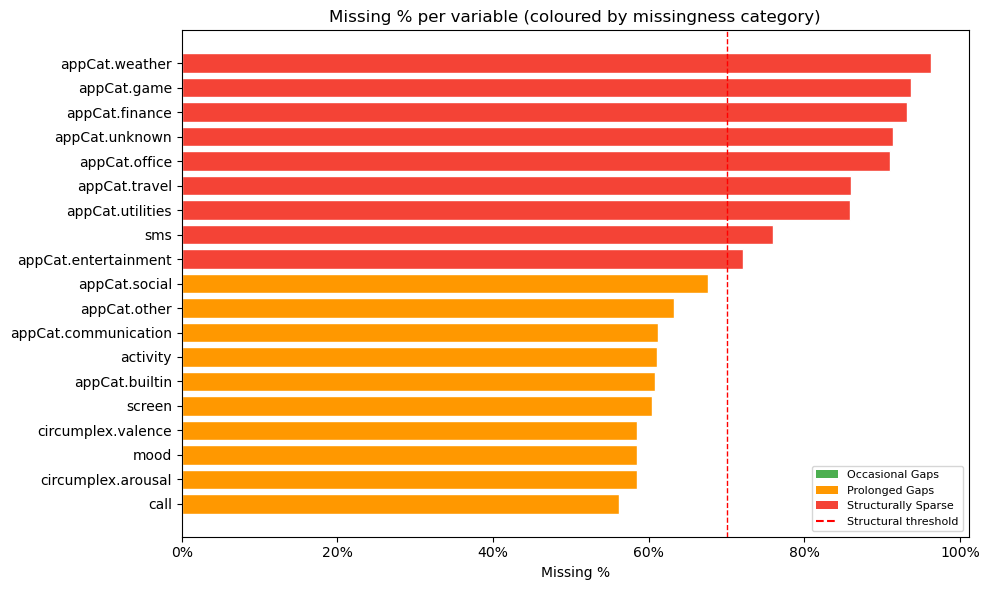

In [14]:
# ── Bar chart: missing % per variable, coloured by category ──────────────
palette = {
    "occasional_gaps":    "#4caf50",
    "prolonged_gaps":     "#ff9800",
    "structurally_sparse": "#f44336",
}

plot_df = classification.sort_values("missing_%", ascending=True).reset_index()
colors  = plot_df["category"].map(palette)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df["variable"], plot_df["missing_%"], color=colors, edgecolor="white")
ax.axvline(STRUCTURAL_PCT, color="red",    linestyle="--", linewidth=1, label=f"Structural threshold ({STRUCTURAL_PCT}%)")
ax.set_xlabel("Missing %")
ax.set_title("Missing % per variable (coloured by missingness category)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k.replace("_", " ").title()) for k, v in palette.items()]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color="red", linestyle="--", label=f"Structural threshold")],
          loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/missingness_by_variable.png", dpi=150)
plt.show()

#### **7. Export**

In [15]:
var_miss.to_csv("../outputs/missingness_per_variable.csv")
patient_miss.to_csv("../outputs/missingness_per_patient.csv")
pv_miss.to_csv("../outputs/missingness_patient_variable.csv", index=False)
streak_summary.to_csv("../outputs/streak_summary.csv")
classification.to_csv("../outputs/missingness_classification.csv")
print("All outputs saved.")

All outputs saved.


#### Why this matters


#### Notes




- **Occasional gaps** (short streaks only): reasonable candidates for time-series-aware imputation like linear interpolation or forward-fill with a short limit.


#### Addititonal Analysis

**49 patient-variable combos are 100% missing; these are structural zeros, not gaps to impute.** appCat.weather affects 15/27 patients, appCat.finance and appCat.game each 12/27. For these patients, the variable was simply never recorded, imputing it would be fabricating data. The notebook note on imputation in 1B should explicitly state: imputation only applies where a patient has *some* observations for a variable; 100% missing combos should stay NaN or be dropped as features for that patient.


**call is the weakest prolonged_gaps case.** Its max_streak is 22 vs 58 for all others in that category, and mean_n_streaks is 13.85 with mean_avg_streak of only 2.26 days; a very fragmented pattern closer to sms than to mood. It may behave better with forward-fill than the other prolonged_gaps variables, since its gaps are short and frequent rather than long and rare.

**AS14.28 is the most problematic patient at the observation level.** 28.4% of its calendar days have no observations at all, consistent with the longest_obs_gap of 8 days from b_03. This patient will lose the most training instances in 1C regardless of imputation strategy.
